In [2]:
import math
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("data/academic Stress level - maintainance 1.csv")
df.head()

,Timestamp,Your Academic Stage,Peer pressure,Academic pressure from your home,Study Environment,What coping strategy you use as a student?,"Do you have any bad habits like smoking, drinking on a daily basis?",What would you rate the academic competition in your student life,Rate your academic stress index
0,24/07/2025 22:05:39,undergraduate,4,5,Noisy,Analyze the situation and handle it with intel...,No,3,5
1,24/07/2025 22:05:52,undergraduate,3,4,Peaceful,Analyze the situation and handle it with intel...,No,3,3
2,24/07/2025 22:06:39,undergraduate,1,1,Peaceful,"Social support (friends, family)",No,2,4
3,24/07/2025 22:06:45,undergraduate,3,2,Peaceful,Analyze the situation and handle it with intel...,No,4,3
4,24/07/2025 22:08:06,undergraduate,3,3,Peaceful,Analyze the situation and handle it with intel...,No,4,5


# Question 1

In [3]:
print(f"Columns from dataset:\n{df.columns.tolist()}\n")

Columns from dataset:
['Timestamp', 'Your Academic Stage', 'Peer pressure', 'Academic pressure from your home', 'Study Environment', 'What coping strategy you use as a student?', 'Do you have any bad habits like smoking, drinking on a daily basis?', 'What would you rate the academic  competition in your student life', 'Rate your academic stress index ']



In [4]:
print(f"Target variable: {df.columns.tolist()[-1]}")
print(f"Variables: {df.columns.tolist()[:-1]}")

Target variable: Rate your academic stress index 
Variables: ['Timestamp', 'Your Academic Stage', 'Peer pressure', 'Academic pressure from your home', 'Study Environment', 'What coping strategy you use as a student?', 'Do you have any bad habits like smoking, drinking on a daily basis?', 'What would you rate the academic  competition in your student life']


In [5]:
print(df["Rate your academic stress index "].value_counts())

Rate your academic stress index 
4    56
3    36
5    33
2     9
1     6
Name: count, dtype: int64


In [6]:
stress_index = df["Rate your academic stress index "].value_counts()
stress_index_df = pd.DataFrame({"Class":stress_index.index, "Frequency":stress_index.values})
stress_index_df

,Class,Frequency
0,4,56
1,3,36
2,5,33
3,2,9
4,1,6


Generating plots for first question

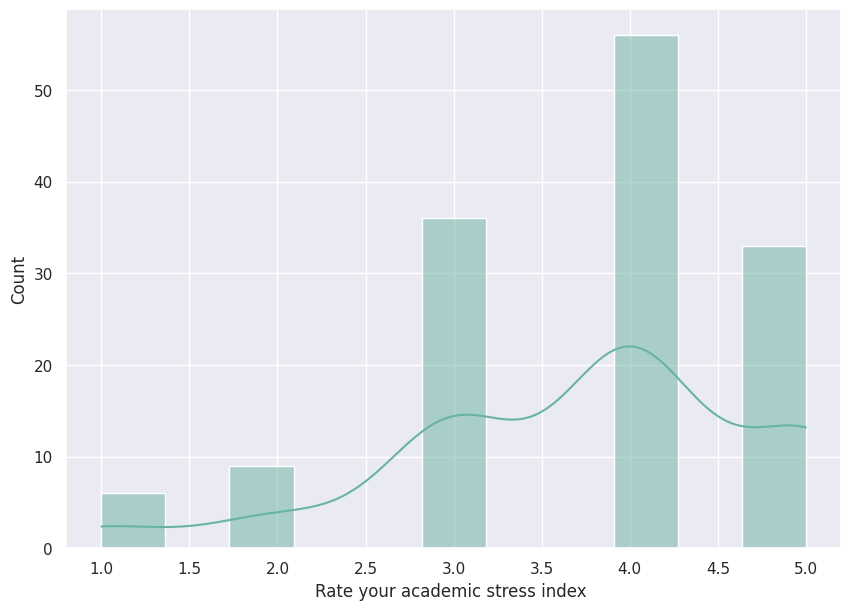

In [7]:
sns.set_theme(style="darkgrid")
plt.figure(figsize=(10, 7))
sns.histplot(data=df["Rate your academic stress index "],
            kde=True,
            color='#69b3a2'
)
plt.show()

# Question 2

Realizar uma análise univariada incondicional para cada uma das features. Criar histogramas análisando a frequência de cada feature no dataset.

PS: para que seja possível realizar as análises seguintes é necessário convertermos os dados categóricos para numéricos, pois dessa forma será possível criarmos histogramas de todas as nossas features (histogramas representa uma distribuição, logo só é válido para valores contínuos)

Exploratory Data Analyze

In [8]:
df.dtypes

Timestamp                                                              object
Your Academic Stage                                                    object
Peer pressure                                                           int64
Academic pressure from your home                                        int64
Study Environment                                                      object
What coping strategy you use as a student?                             object
Do you have any bad habits like smoking, drinking on a daily basis?    object
What would you rate the academic  competition in your student life      int64
Rate your academic stress index                                         int64
dtype: object

Selecting mainly features

In [9]:
df = df.drop(["Timestamp"], axis=1) #Remove Timestamp. Doesn't necessary for our analyze
df.columns.tolist()

['Your Academic Stage',
 'Peer pressure',
 'Academic pressure from your home',
 'Study Environment',
 'What coping strategy you use as a student?',
 'Do you have any bad habits like smoking, drinking on a daily basis?',
 'What would you rate the academic  competition in your student life',
 'Rate your academic stress index ']

In [10]:
df["Your Academic Stage"].value_counts()

Your Academic Stage
undergraduate    100
high school       29
post-graduate     11
Name: count, dtype: int64

In [11]:
df["Study Environment"].value_counts()

Study Environment
Peaceful     69
disrupted    38
Noisy        32
Name: count, dtype: int64

In [12]:
print(df["What coping strategy you use as a student?"].value_counts())

What coping strategy you use as a student?
Analyze the situation and handle it with intellect    87
Emotional breakdown (crying a lot)                    32
Social support (friends, family)                      21
Name: count, dtype: int64


In [13]:
print(df["Do you have any bad habits like smoking, drinking on a daily basis?"].value_counts())

Do you have any bad habits like smoking, drinking on a daily basis?
No                   123
Yes                   10
prefer not to say      7
Name: count, dtype: int64


Reduce column/value size name

In [14]:
# Modify the values from this column

mapping = {
    "Analyze the situation and handle it with intellect": "Think strategically",
    "Emotional breakdown (crying a lot)": "Emotional breakdown",
    "Social support (friends, family)": "Social support"
}

df["What coping strategy you use as a student?"] = df["What coping strategy you use as a student?"].map(mapping)
df["What coping strategy you use as a student?"].value_counts()

What coping strategy you use as a student?
Think strategically    87
Emotional breakdown    32
Social support         21
Name: count, dtype: int64

In [15]:
mapping = {
    "No": "No",
    "Yes": "Yes",
    "prefer not to say":"I abstain"
}

df["Do you have any bad habits like smoking, drinking on a daily basis?"] = df["Do you have any bad habits like smoking, drinking on a daily basis?"].map(mapping)
df["Do you have any bad habits like smoking, drinking on a daily basis?"].value_counts()

Do you have any bad habits like smoking, drinking on a daily basis?
No           123
Yes           10
I abstain      7
Name: count, dtype: int64

In [16]:
df = df.rename(columns={
    'Peer pressure': 'Social Pressure',
    'Academic pressure from your home': 'Family Pressure',
    'Your Academic Stage': 'Academic Stage',
    'Study Environment': 'Study Environment',
    'What coping strategy you use as a student?': 'Coping Strategy',
    'Do you have any bad habits like smoking, drinking on a daily basis?': 'Bad Habits'
})

Codification

In [17]:
# View all categorical columns

cat_cols = df.select_dtypes(include=['object', 'category', 'string']).columns.tolist()
print(cat_cols)

['Academic Stage', 'Study Environment', 'Coping Strategy', 'Bad Habits']


In [18]:
df[cat_cols]

,Academic Stage,Study Environment,Coping Strategy,Bad Habits
0,undergraduate,Noisy,Think strategically,No
1,undergraduate,Peaceful,Think strategically,No
2,undergraduate,Peaceful,Social support,No
3,undergraduate,Peaceful,Think strategically,No
4,undergraduate,Peaceful,Think strategically,No
...,...,...,...,...
135,undergraduate,Peaceful,Think strategically,No
136,undergraduate,disrupted,Think strategically,No
137,undergraduate,Peaceful,Think strategically,No
138,undergraduate,disrupted,Social support,No


In [19]:
# Using Ordinal Encoder (Any categorical data need importance for maintain sequence data)

import sklearn.preprocessing as ce

encoder = ce.OrdinalEncoder()
df[cat_cols] = encoder.fit_transform(df[cat_cols]).astype(int)

ModuleNotFoundError: No module named 'sklearn'

In [ ]:
df["Study Environment"].value_counts()

Study Environment
 1                      69
 2                      38
 0                      32
-9223372036854775808     1
Name: count, dtype: int64

In [ ]:
# Removing row with encoded incorrectly data

df = df[df['Study Environment'] != -9223372036854775808]

In [ ]:
df["Study Environment"].value_counts()

Study Environment
1    69
2    38
0    32
Name: count, dtype: int64

In [ ]:
df.dtypes

Academic Stage                                                        int64
Social Pressure                                                       int64
Family Pressure                                                       int64
Study Environment                                                     int64
Coping Strategy                                                       int64
Bad Habits                                                            int64
What would you rate the academic  competition in your student life    int64
Rate your academic stress index                                       int64
dtype: object

In [ ]:
print("Some statistical informations about the data:")
df.describe()

Some statistical informations about the data:


,Academic Stage,Social Pressure,Family Pressure,Study Environment,Coping Strategy,Bad Habits,What would you rate the academic competition in your student life,Rate your academic stress index
count,139.000000,139.000000,139.000000,139.000000,139.000000,139.000000,139.000000,139.000000
mean,1.503597,3.057554,3.165468,1.043165,1.402878,1.021583,3.482014,3.719424
std,0.819810,1.075213,1.271751,0.710894,0.831616,0.350313,1.024005,1.035800
min,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000
25%,1.000000,2.000000,2.000000,1.000000,1.000000,1.000000,3.000000,3.000000
50%,2.000000,3.000000,3.000000,1.000000,2.000000,1.000000,4.000000,4.000000
75%,2.000000,4.000000,4.000000,2.000000,2.000000,1.000000,4.000000,4.000000
max,2.000000,5.000000,5.000000,2.000000,2.000000,2.000000,5.000000,5.000000


Remove duplicate spaces on dataframe

In [ ]:
import re

df = df.rename(columns=lambda c: re.sub(r"\s+", " ", ("" if c is None else str(c))).strip())
df.columns.tolist()

['Academic Stage',
 'Social Pressure',
 'Family Pressure',
 'Study Environment',
 'Coping Strategy',
 'Bad Habits',
 'What would you rate the academic competition in your student life',
 'Rate your academic stress index']

Calculate metrics (mean, std and skews)

In [ ]:
from scipy.stats import skew

def calculate_metrics(df):

    means = df.mean()           # μ_d
    stds = df.std(ddof=0)       # σ_d (padrão populacional)
    skews = df.apply(lambda x: skew(x, bias=False))  # γ_d (assimetria de Fisher)

    # combina em um DataFrame para visualização
    metrics_df = pd.DataFrame({
        'Mean (μ)': means,
        'Std (σ)': stds,
        'Skewness (γ)': skews
    })
    return metrics_df

In [ ]:
# Incondicional
calculate_metrics(df)

,Mean (μ),Std (σ),Skewness (γ)
Academic Stage,1.503597,0.816856,-1.172587
Social Pressure,3.057554,1.071339,-0.115767
Family Pressure,3.165468,1.267168,-0.101600
Study Environment,1.043165,0.708332,-0.062261
Coping Strategy,1.402878,0.828620,-0.874894
Bad Habits,1.021583,0.349051,0.325292
What would you rate the academic competition in your student life,3.482014,1.020315,-0.505430
Rate your academic stress index,3.719424,1.032067,-0.723155


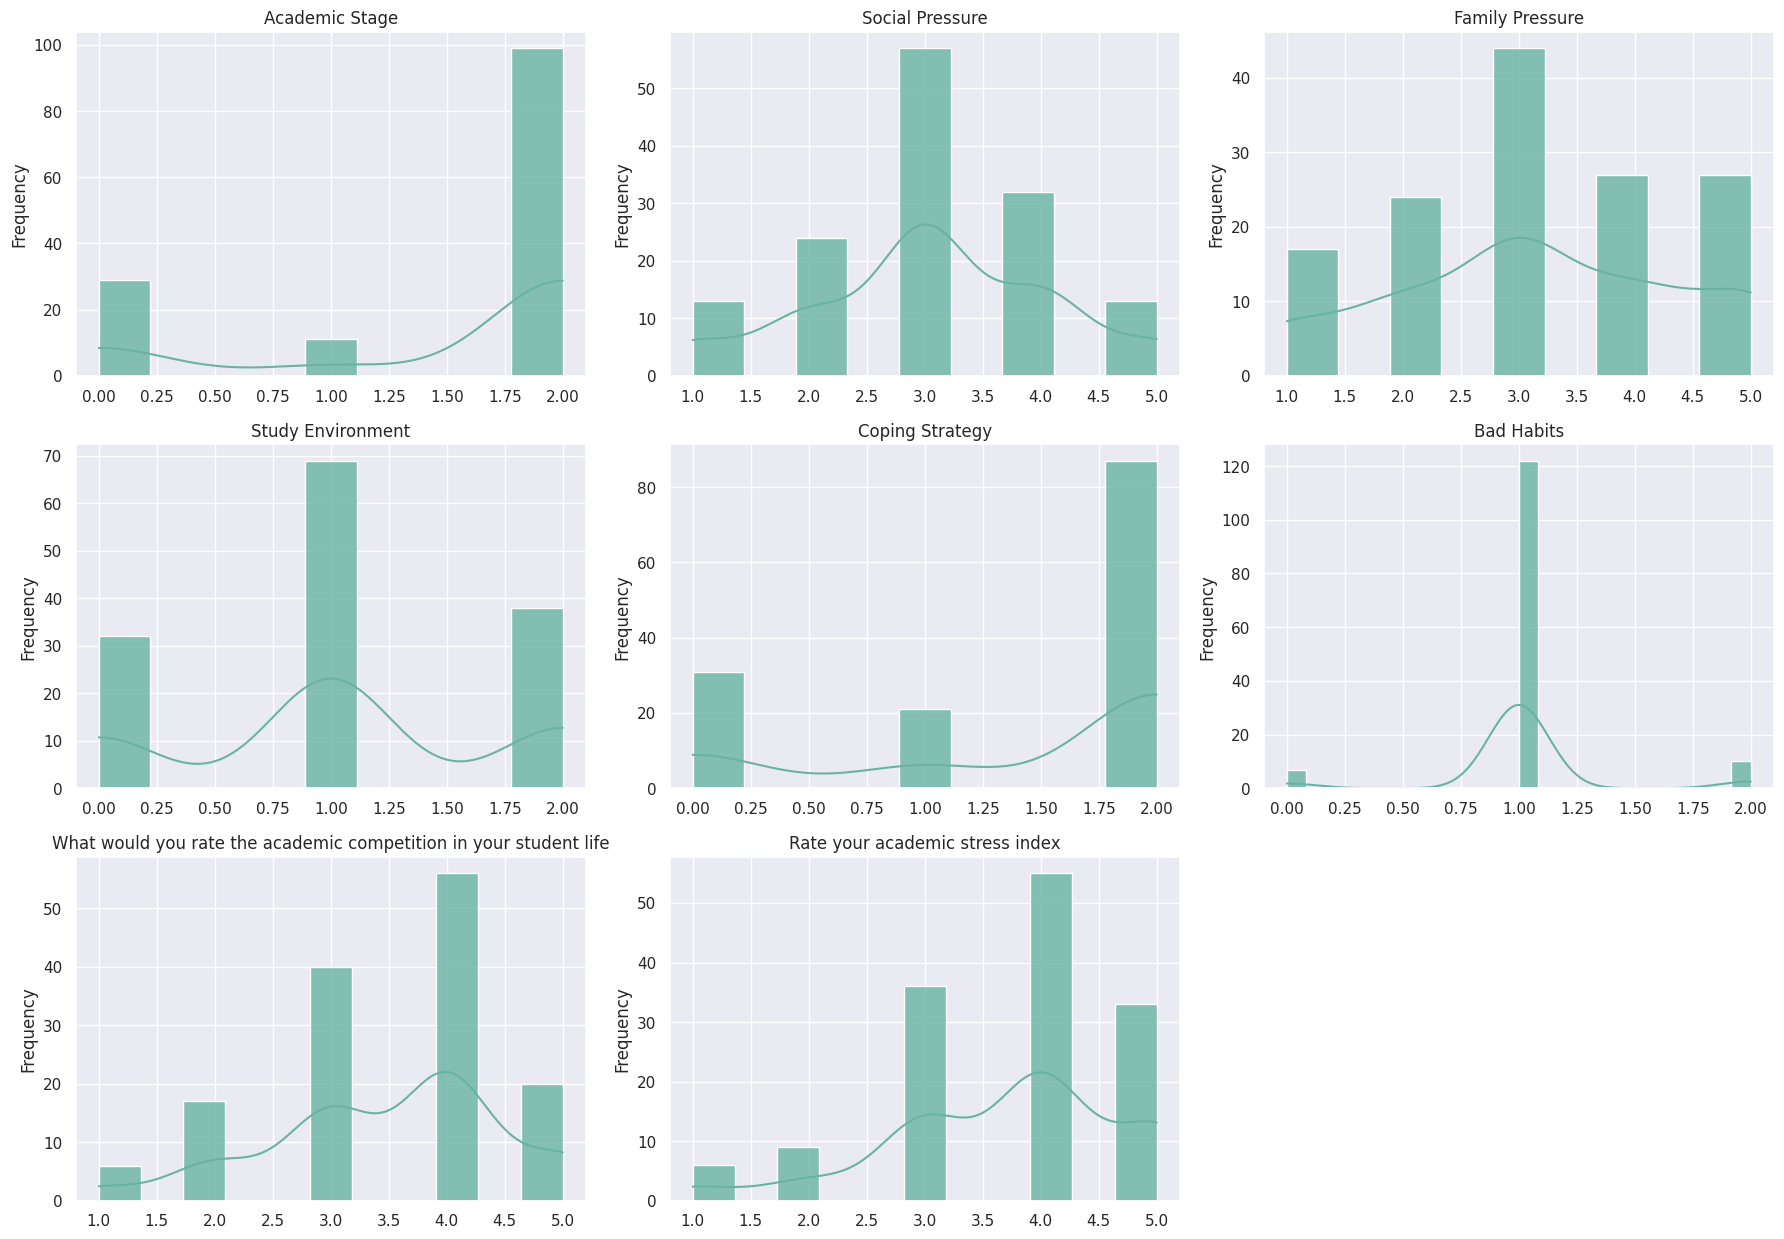


Processo concluído! Todas as figuras foram salvas.


In [ ]:
target_column = 'Rate your academic stress index'
all_columns = df.columns.tolist()

total_plots = len(all_columns)
num_cols = 3
num_rows = math.ceil(total_plots / num_cols) # Estimate number of rows

# Cria a figura e a grade de subplots vazia
fig, axes = plt.subplots(num_rows, num_cols, figsize=(18, num_rows * 4.5))
axes = axes.flatten()

plot_index = 0
alpha_value = 0.8

for col in all_columns:
    ax = axes[plot_index]
    sns.histplot(data=df, 
                    x=col, 
                    ax=ax, 
                    color='#69b3a2', 
                    kde=True,
                    alpha=alpha_value)
    ax.set_title(col)
    ax.set_ylabel("Frequency")
    ax.set_xlabel('')
    plot_index += 1

    
for i in range(plot_index, len(axes)):
    axes[i].set_visible(False)

# Adiciona um título geral para toda a figura
#fig.suptitle(f'Analyze for "{classe}" of academic stress index', fontsize=22)

# Ajusta o espaçamento para evitar que os títulos e rótulos se sobreponham
fig.tight_layout(rect=[0, 0.03, 1, 0.96])

plt.savefig(f"question_2.png")
plt.show()

print("\nProcesso concluído! Todas as figuras foram salvas.")

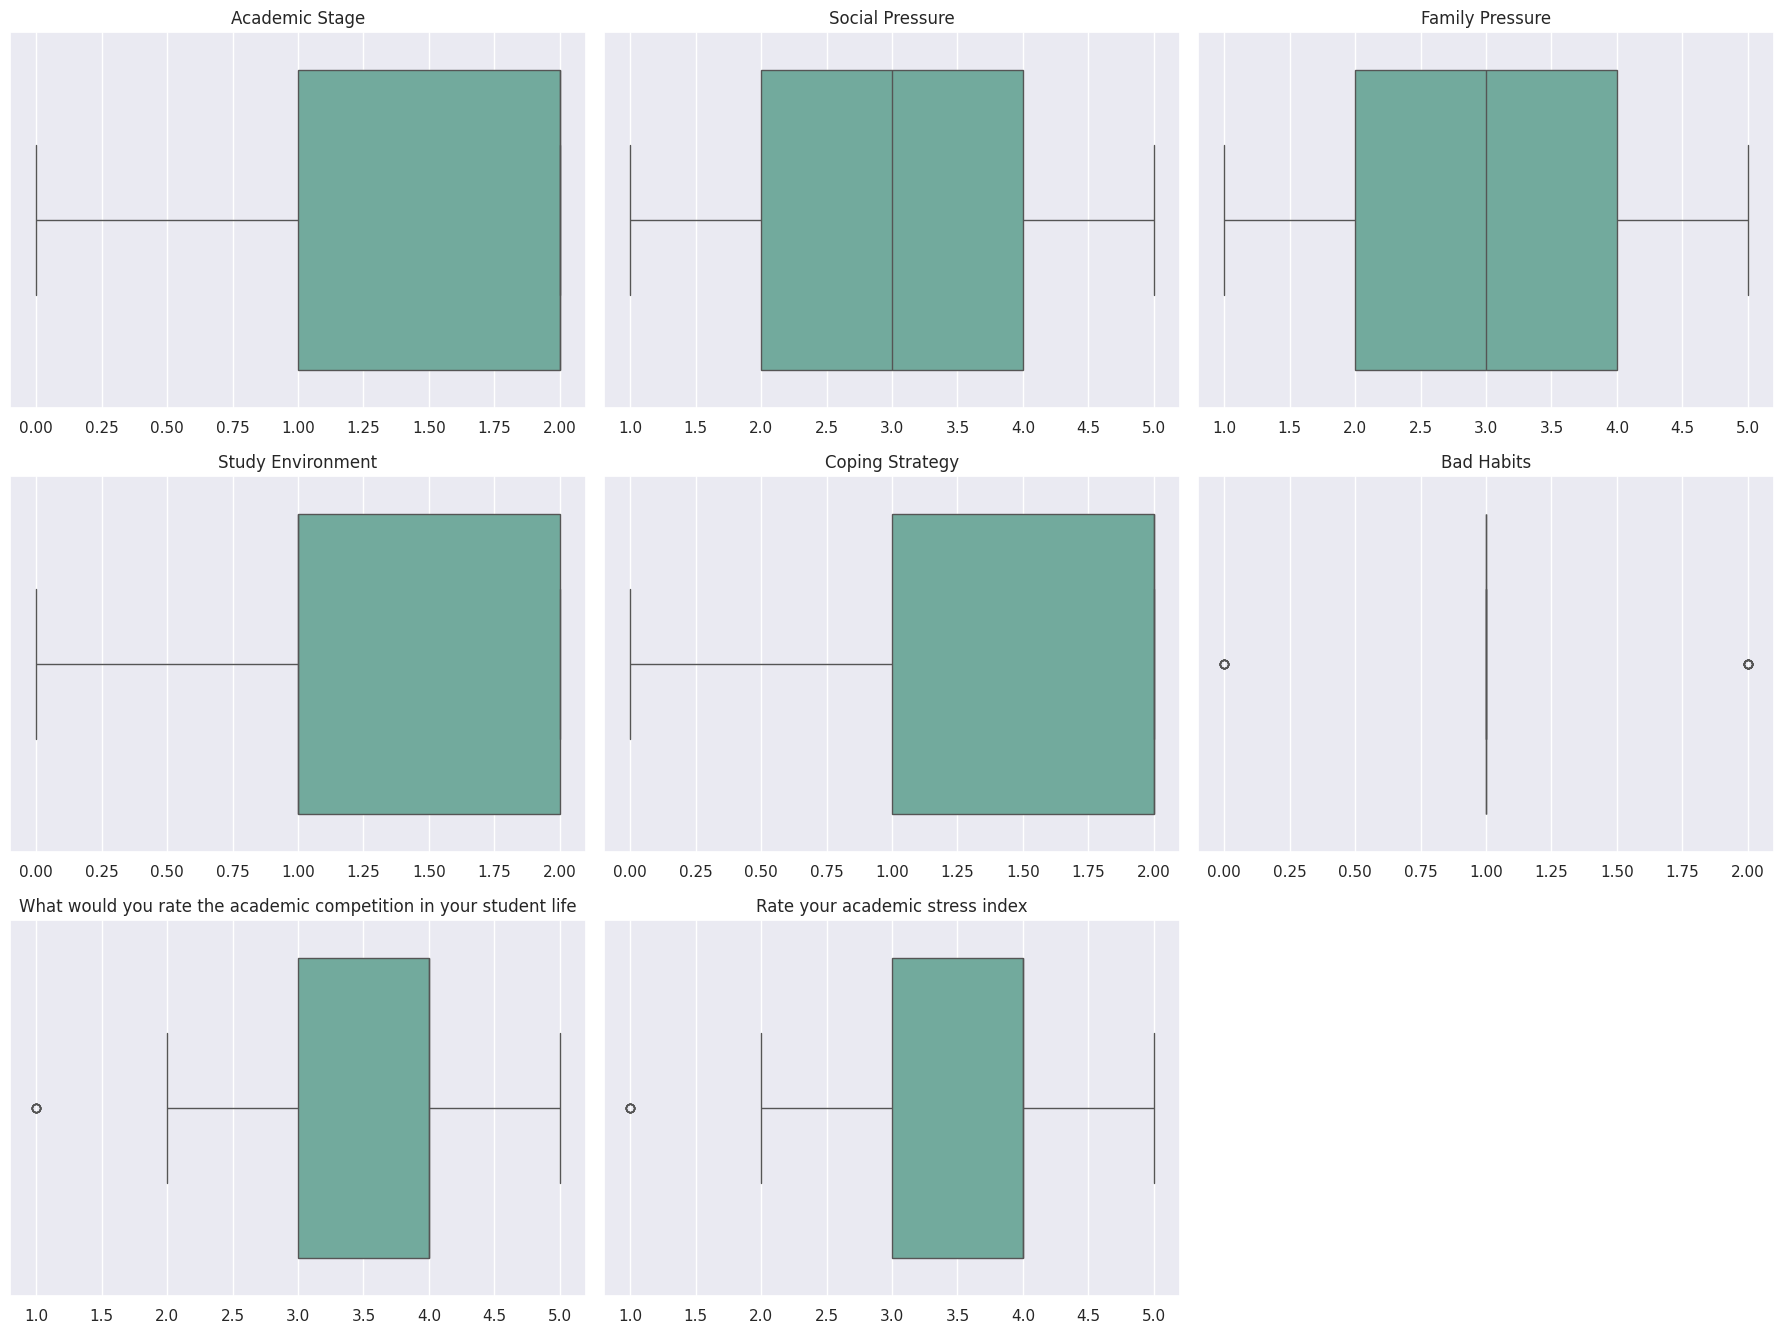


Processo concluído!


In [ ]:
fig, axes = plt.subplots(num_rows, num_cols, figsize=(18, num_rows * 4.5))
axes = np.array(axes).flatten()

plot_index = 0

for col in all_columns:
    ax = axes[plot_index]
    sns.boxplot(x=df[col], ax=ax, color='#69b3a2')
    ax.set_title(col)
    ax.set_xlabel('')
    ax.set_ylabel('')
    plot_index += 1

for j in range(plot_index, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.savefig(f"question_2_boxplot.png")
plt.show()

print("\nProcesso concluído!")


# Question 3

In [ ]:
estatisticas = []
covariancias = {}
correlacoes = {}

# Loop por classe
for l in unique_classes:
    subset = df[df[target_column] == l]  # N_l observações
    for d in numerical_columns:
        valores = subset[d].dropna()
        mu = valores.mean()
        sigma = valores.std()
        gamma = skew(valores)
        subset = df[df[target_column] == l][numerical_columns]
        estatisticas.append({
            'classe': l,
            'variável': d,
            'μ_d|l': mu,
            'σ_d|l': sigma,
            'γ_d|l': gamma,
        })

        covariancias[l] = subset.cov()
        correlacoes[l] = subset.corr()

estat_df = pd.DataFrame(estatisticas)
print(estat_df)

   classe         variável     μ_d|l     σ_d|l     γ_d|l
0       1  Social Pressure  1.666667  1.211060  1.425326
1       1  Family Pressure  1.666667  0.816497  0.626099
2       2  Social Pressure  2.333333  0.866025  0.544331
3       2  Family Pressure  2.222222  0.971825  0.413737
4       3  Social Pressure  2.694444  0.950772 -0.167585
5       3  Family Pressure  3.000000  1.146423  0.000000
6       4  Social Pressure  3.196429  0.902917 -0.095894
7       4  Family Pressure  3.178571  1.161616 -0.141353
8       5  Social Pressure  3.727273  1.068665 -0.531215
9       5  Family Pressure  3.909091  1.307757 -0.937176


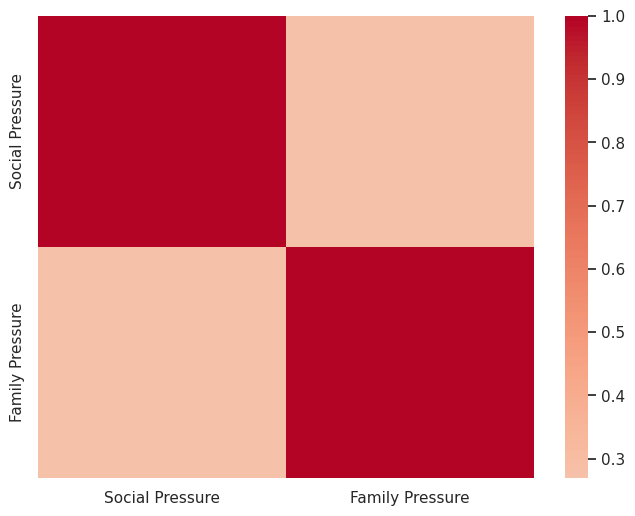

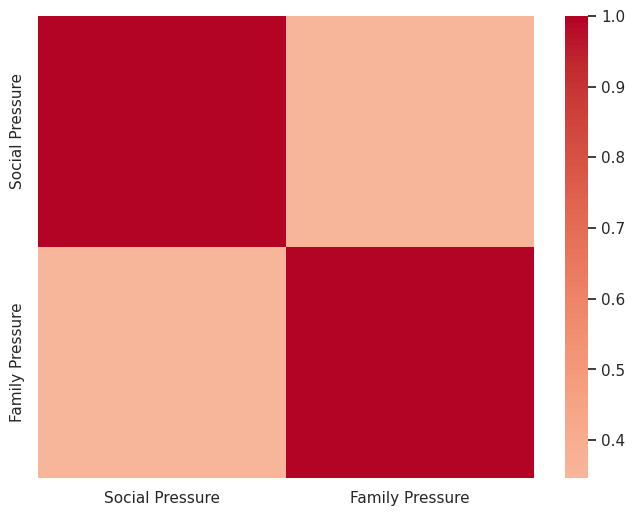

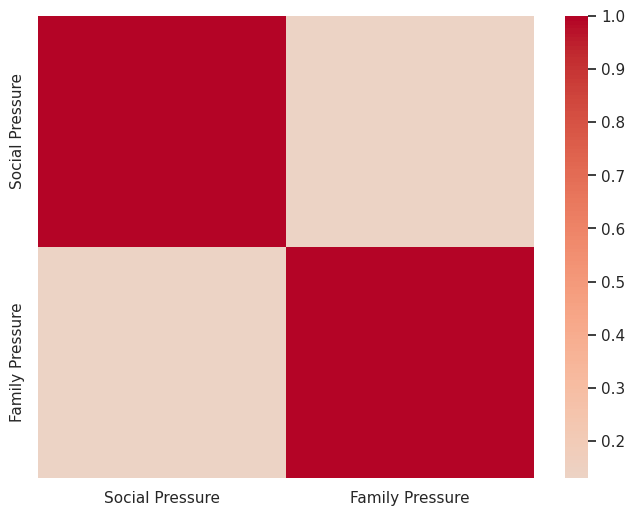

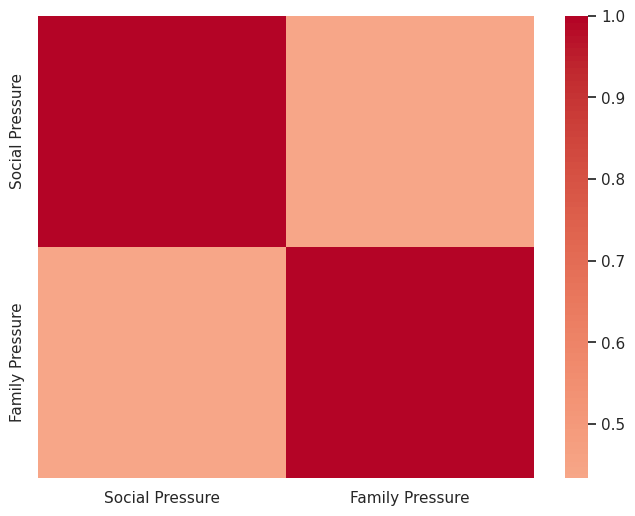

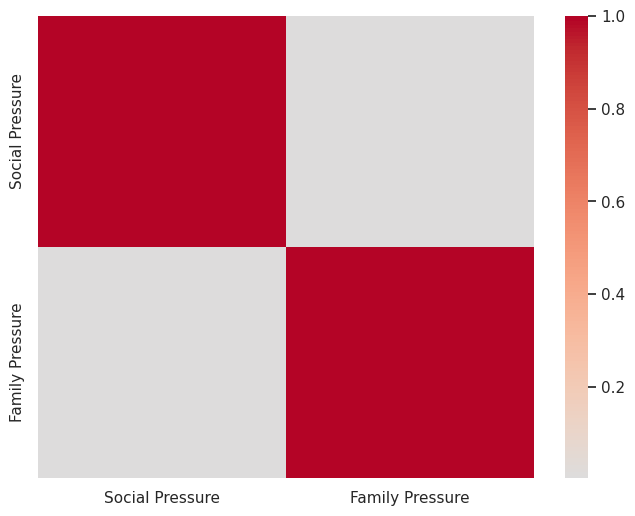

In [ ]:
for l, corr_matrix in correlacoes.items():
    plt.figure(figsize=(8,6))
    sns.heatmap(corr_matrix, cmap='coolwarm', center=0, annot=False)
    plt.savefig(f"matriz_corr_{classe}.png")
    plt.show()


In [ ]:
all_columns = df.columns[:-1]

# Question 4

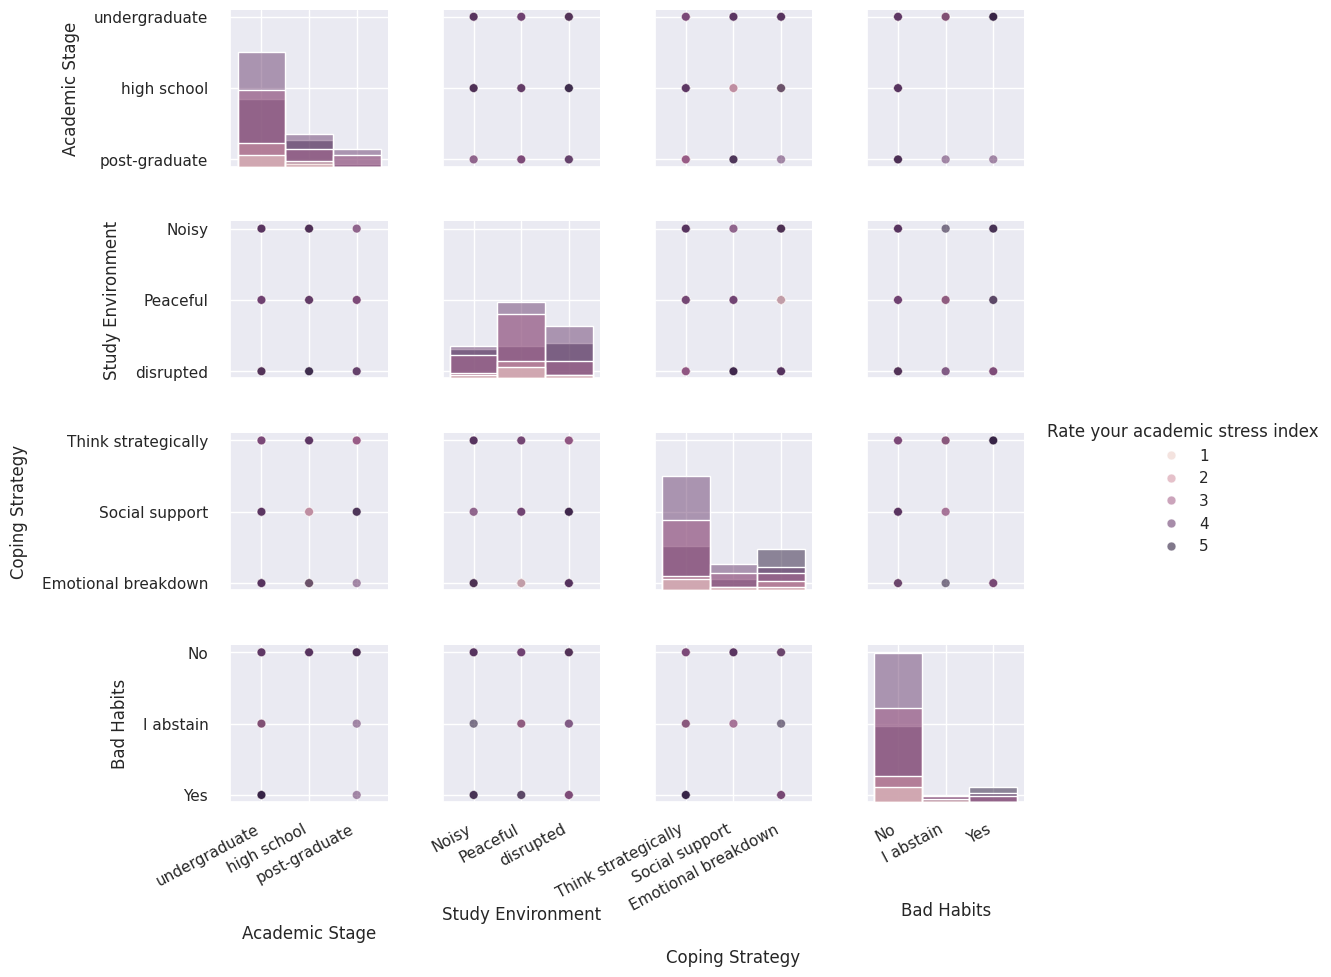

In [ ]:
g = sns.pairplot(
    df,
    vars=categorical_columns,       # todas as combinações de pares
    hue=target_column,          # cor conforme classe
    diag_kind='hist',      # tipo de gráfico na diagonal
    plot_kws={'alpha':0.6, 's':40},
    height=2.6
)
g.fig.subplots_adjust(wspace=0.35, hspace=0.35, bottom=0.22)

for ax in g.axes.flatten():
    if ax is None:
        continue
    ax.xaxis.labelpad = 10   # espaço entre eixo X e nome da coluna
    ax.yaxis.labelpad = 10   # espaço entre eixo Y e nome da coluna
    ax.tick_params(axis='x', pad=6)  # espaço entre eixo X e ticks
    ax.tick_params(axis='y', pad=10)  # espaço entre eixo Y e ticks

for ax in g.axes[-1, :]:
    if ax is None: 
        continue
    ax.xaxis.labelpad = 26
    ax.tick_params(axis='x', pad=8)
    for lbl in ax.get_xticklabels():
        lbl.set_rotation(28)
        lbl.set_ha('right')

plt.savefig(f"analise_bivariada_incondicional{classe}.png")
plt.show()

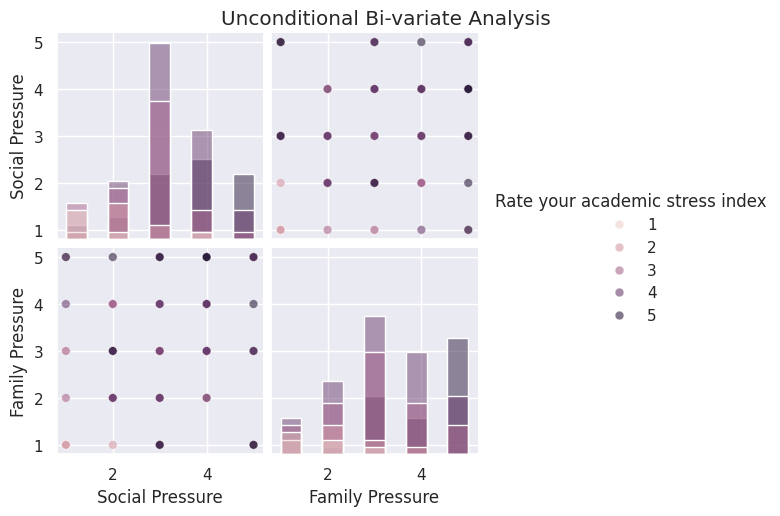

In [ ]:
sns.pairplot(
    df,
    vars=numerical_columns,      
    hue=target_column,          
    diag_kind='hist',      
    plot_kws={'alpha':0.6, 's':40}  
)
plt.savefig(f"analise_bivariada_incondicional_numerica{classe}.png")
plt.show()

# Question 5

In [ ]:
# O primeiro passo para aplicar o PCA, é centralizar os dados
def center(X):
    return X - np.mean(X, axis=0)

# O segundo passo para aplicar o PCA, é encontrar a matriz de covariância
def mcov(X):
    # N corresponde ao número de amostras (linhas)
    # p corresponde ao número de características (colunas)
    N, p = X.shape

    # m é a média de cada coluna (característica)
    m = np.mean(X, axis=0)

    # R é a matriz de correlação
    # C é a matriz de covariância
    R = (X.T @ X)/N
    C = R - m.reshape(p,1)@m.reshape(p,1).T
    return C

# O próximo passo é calcular os autovalores e autovetores da matriz de covariância 
# Calculamos as raízes do determinante |C - λI| = 0, onde I é a matriz identidade p x p
def autovalores_autovetores (C):
    autovalores, autovetores = np.linalg.eig(C)
    return autovalores, autovetores 

 # Agora, precisamos ordenar os autovalores e autovetores

# A função esta adaptada para selecionar os N maiores autovalores e seus respectivos autovetores

def matriz_projecao(autovalores, autovetores, N_components):
    idx = autovalores.argsort()[::-1]

    autovalores = autovalores[idx]
    autovetores = autovetores[:,idx]

    V = autovetores[:,:N_components]
    return V 
 
# Algebricamente, seria necessário calcular a matriz de transformação Q = V.T, mas como estamos trabalhando com numpy, podemos usar diretamente V
# Finalmente, aplicamos a transformação PCA

def pca_transformacao(X, V):
    Y = X @ V
    return Y

In [ ]:
# Agora, desenvolvemos a função completa de PCA
def pca(X):
    X = center(X)
    N, p = X.shape

    C = mcov(X)

    autovalores, autovetores = autovalores_autovetores(C, p)

    V = matriz_projecao(autovalores, autovetores, p)
    Y = pca_transformacao(X, V)

    return Y 